In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving spam_detection.csv to spam_detection.csv


In [ ]:
df = pd.read_csv('spam_detection.csv', encoding='latin-1')

# Extra empty columns remove
df = df[['v1', 'v2']]

print(df.head())

     v1                                                 v2
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [ ]:
print(df.shape)

print(df['v1'].value_counts())

(5572, 2)
v1
ham     4825
spam     747
Name: count, dtype: int64


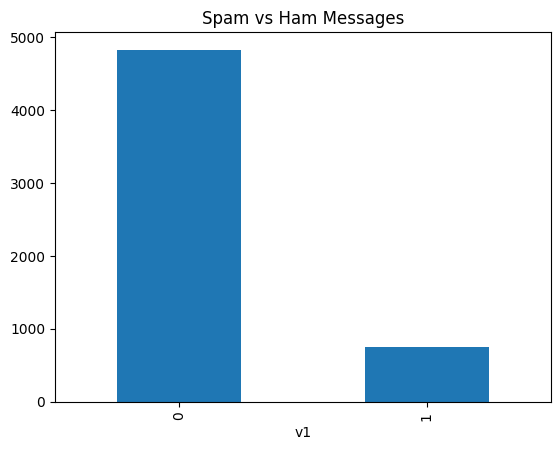

In [ ]:
import matplotlib.pyplot as plt

df['v1'].value_counts().plot(kind='bar')

plt.title('Spam vs Ham Messages')
plt.show()

In [ ]:
df['v1'] = df['v1'].map({
    'ham':0,
    'spam':1
})

In [ ]:
X = df['v2']
y = df['v1']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [ ]:
y_pred = model.predict(X_test_tfidf)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9668161434977578


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



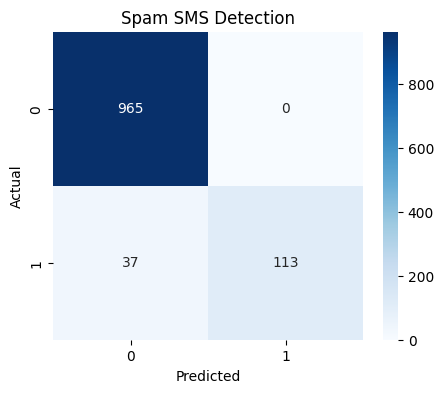

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Spam SMS Detection")
plt.show()

In [ ]:
message = [
    "Congratulations! You won 50000 rupees. Call now."
]

msg_vector = vectorizer.transform(message)

prediction = model.predict(msg_vector)

if prediction[0] == 1:
    print("SPAM")
else:
    print("HAM")

SPAM
